In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


import kagglehub

# Download latest version
path = kagglehub.dataset_download("matthewjansen/ucf101-action-recognition")

print("Path to dataset files:", path)
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
# Fix for AttributeError: 'MessageFactory' (Run this FIRST and RESTART KERNEL if needed)
# !pip uninstall -y protobuf -q
# !pip install protobuf==4.21.5 -q

import os

# Based on your image 57723c.png, the correct path is:
VIDEO_PATH = "/kaggle/input/ucf101-action-recognition/train" 

# Verify path immediately
# if os.path.exists(VIDEO_PATH):
#     num_vids = sum([len(files) for r, d, files in os.walk(VIDEO_PATH)])
#     print(f"✅ Path found! Detected {num_vids} videos.")
# else:
#     print(f"❌ ERROR: Path {VIDEO_PATH} not found. Check the Sidebar.")

In [ ]:
# !pip install bigframes google-cloud-bigquery-storage

In [ ]:
# import os
# import cv2
# import torch
# import torch.nn as nn
# import numpy as np
# from torch.utils.data import DataLoader, Dataset
# from diffusers import UNet3DConditionModel, DDPMScheduler
# import torchvision.transforms as T
# from tqdm.notebook import tqdm
# import imageio

# # --- CONFIGURATION ---
# VIDEO_PATH = "/kaggle/input/ucf101-action-recognition/train" # Adjust based on Kaggle input name
# if not os.path.exists(VIDEO_PATH):
#     # Fallback: Download a small subset if dataset isn't attached
#     !wget -q https://raw.githubusercontent.com/sayakpaul/Video-Diffusion-PyTorch/main/data/sample_videos.tar.gz
#     !tar -xzf sample_videos.tar.gz
#     VIDEO_PATH = "./sample_videos"

# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# IMG_SIZE = 64        # Start small for from-scratch training
# FRAMES = 16          # Standard clip length
# BATCH_SIZE = 4
# EPOCHS = 50

# # --- STEP 1: REAL-WORLD VIDEO DATASET ---
# class VideoDataset(Dataset):
#     def __init__(self, root_dir, frame_count=16, image_size=64):
#         self.video_files = []
#         for root, _, files in os.walk(root_dir):
#             for f in files:
#                 if f.endswith(('.mp4', '.avi')):
#                     self.video_files.append(os.path.join(root, f))
        
#         self.frame_count = frame_count
#         self.transform = T.Compose([
#             T.ToPILImage(),
#             T.Resize((image_size, image_size)),
#             T.CenterCrop(image_size),
#             T.ToTensor(),
#             T.Normalize([0.5], [0.5]) # Diffusion models prefer [-1, 1]
#         ])

#     def __len__(self):
#         return len(self.video_files)

#     def __getitem__(self, idx):
#         cap = cv2.VideoCapture(self.video_files[idx])
#         frames = []
#         total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
#         # Simple sampling: grab consecutive frames from the middle
#         start_frame = max(0, (total_frames // 2) - (self.frame_count // 2))
#         cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

#         while len(frames) < self.frame_count:
#             ret, frame = cap.read()
#             if not ret: break
#             frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#             frames.append(self.transform(frame))
#         cap.release()

#         # If video is too short, pad with last frame
#         while len(frames) < self.frame_count:
#             frames.append(frames[-1])

#         # Return as (Channels, Frames, Height, Width)
#         return torch.stack(frames).permute(1, 0, 2, 3)

# # --- STEP 2: 3D-UNET ARCHITECTURE (The "Brain") ---
# # We use a 3D-UNet which applies convolutions across Space AND Time
# model = UNet3DConditionModel(
#     sample_size=IMG_SIZE,
#     in_channels=3,
#     out_channels=3,
#     layers_per_block=2,
#     block_out_channels=(64, 128, 256, 256),
#     down_block_types=("DownBlock3D", "DownBlock3D", "DownBlock3D", "DownBlock3D"),
#     up_block_types=("UpBlock3D", "UpBlock3D", "UpBlock3D", "UpBlock3D"),
# ).to(DEVICE)

# # --- STEP 3: DIFFUSION SETUP ---
# noise_scheduler = DDPMScheduler(num_train_timesteps=1000)
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
# criterion = nn.MSELoss()

# # --- STEP 4: TRAINING LOOP ---
# dataset = VideoDataset(VIDEO_PATH, frame_count=FRAMES, image_size=IMG_SIZE)
# loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# print(f"Starting 'From Scratch' training on {len(dataset)} videos...")

# for epoch in range(EPOCHS):
#     model.train()
#     epoch_loss = 0
#     pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
#     for batch in pbar:
#         clean_videos = batch.to(DEVICE)
        
#         # 1. Sample Noise
#         noise = torch.randn_like(clean_videos)
#         bs = clean_videos.shape[0]
        
#         # 2. Sample random timesteps
#         timesteps = torch.randint(0, 1000, (bs,), device=DEVICE).long()
        
#         # 3. Add noise to the videos (Forward Process)
#         noisy_videos = noise_scheduler.add_noise(clean_videos, noise, timesteps)
        
#         # 4. Predict the noise (Reverse Process)
#         # In this 'from scratch' version, we don't pass a text prompt
#         noise_pred = model(noisy_videos, timesteps).sample
        
#         # 5. Calculate Loss and Backprop
#         loss = criterion(noise_pred, noise)
#         loss.backward()
#         optimizer.step()
#         optimizer.zero_grad()
        
#         epoch_loss += loss.item()
#         pbar.set_postfix(mse=loss.item())

#     print(f"Epoch {epoch+1} Avg Loss: {epoch_loss/len(loader):.6f}")

# # --- STEP 5: INFERENCE & SAVING ---
# torch.save(model.state_dict(), "video_gen_scratch.pt")

# def generate_video(filename="scratch_gen.gif"):
#     model.eval()
#     with torch.no_grad():
#         # Start with pure noise
#         pipeline_output = torch.randn((1, 3, FRAMES, IMG_SIZE, IMG_SIZE)).to(DEVICE)
        
#         # Denoise step-by-step
#         for t in tqdm(noise_scheduler.timesteps, desc="Generating"):
#             # Predict noise residual
#             noise_pred = model(pipeline_output, t).sample
#             # Compute previous noisy sample
#             pipeline_output = noise_scheduler.step(noise_pred, t, pipeline_output).prev_sample
            
#         # Post-process: [-1, 1] -> [0, 255]
#         video = ((pipeline_output[0].permute(1, 2, 3, 0).cpu().numpy() * 0.5 + 0.5) * 255).astype(np.uint8)
#         imageio.mimsave(filename, video, fps=8)
#         print(f"✅ Video generated at /kaggle/working/{filename}")

# generate_video()

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from diffusers import UNet3DConditionModel, DDPMScheduler
import torchvision.transforms as T
import cv2
import numpy as np
from tqdm.notebook import tqdm
import os
import gc
from torch.amp import autocast, GradScaler

# --- AGGRESSIVE CLEANUP ---
gc.collect()
torch.cuda.empty_cache()

# --- STEP 1: LIGHTWEIGHT DATASET (8 Frames) ---
class VideoDataset(Dataset):
    def __init__(self, root_dir, frame_count=8, image_size=64):
        self.video_files = []
        for root, _, files in os.walk(root_dir):
            for f in files:
                if f.endswith(('.mp4', '.avi')):
                    self.video_files.append(os.path.join(root, f))
        self.frame_count = frame_count
        self.transform = T.Compose([
            T.ToPILImage(), T.Resize((image_size, image_size)),
            T.CenterCrop(image_size), T.ToTensor(), T.Normalize([0.5], [0.5])
        ])

    def __len__(self): return len(self.video_files)

    def __getitem__(self, idx):
        cap = cv2.VideoCapture(self.video_files[idx])
        frames = []
        total_v_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        indices = np.linspace(0, total_v_frames - 1, self.frame_count).astype(int)
        for i in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, i)
            ret, frame = cap.read()
            if not ret: break
            frames.append(self.transform(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))
        cap.release()
        while len(frames) < self.frame_count: frames.append(frames[-1])
        return torch.stack(frames).permute(1, 0, 2, 3)

# --- CUSTOM WRAPPER FOR DATAPARALLEL COMPATIBILITY ---
class DiffusersModelWrapper(nn.Module):
    """Wrapper to make diffusers models compatible with DataParallel"""
    def __init__(self, model):
        super().__init__()
        self.model = model
    
    def forward(self, sample, timesteps, encoder_hidden_states):
        # Force return_dict=False to get tuple output that DataParallel can handle
        output = self.model(
            sample, 
            timesteps, 
            encoder_hidden_states=encoder_hidden_states,
            return_dict=False
        )
        # Return only the first element (noise prediction)
        return output[0]

# --- STEP 2: FIXED MODEL CONFIG ---
DEVICE = "cuda"

# FIXED: Set 'attention_head_dim' explicitly to 8 to avoid ZeroDivisionError
base_model = UNet3DConditionModel(
    sample_size=64,
    in_channels=3,
    out_channels=3,
    cross_attention_dim=768,
    attention_head_dim=8,  # <--- CRITICAL FIX
    block_out_channels=(32, 64, 128, 128), 
    down_block_types=("CrossAttnDownBlock3D", "CrossAttnDownBlock3D", "CrossAttnDownBlock3D", "DownBlock3D"),
    up_block_types=("UpBlock3D", "CrossAttnUpBlock3D", "CrossAttnUpBlock3D", "CrossAttnUpBlock3D"),
).to(DEVICE)

base_model._supports_gradient_checkpointing = True 
base_model.enable_gradient_checkpointing()

# Wrap the model for DataParallel compatibility
model = DiffusersModelWrapper(base_model)

# Apply DataParallel if multiple GPUs available
num_gpus = torch.cuda.device_count()
if num_gpus > 1:
    print(f"✅ Using {num_gpus} GPUs with DataParallel!")
    model = nn.DataParallel(model)
    using_dataparallel = True
else:
    print("Using single GPU")
    using_dataparallel = False

noise_scheduler = DDPMScheduler(num_train_timesteps=1000)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
scaler = GradScaler('cuda')

# --- STEP 3: TRAINING ---
# Batch size should be divisible by number of GPUs
BATCH_SIZE = 2 * num_gpus  # 2 videos per GPU
ACCUMULATION_STEPS = 4 
VIDEO_PATH = "/kaggle/input/ucf101-action-recognition/train"

dataset = VideoDataset(VIDEO_PATH, frame_count=8)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True, num_workers=2)

print(f"Batch size: {BATCH_SIZE} (across {num_gpus} GPU(s))")
print("Starting Fixed Lightweight Training...")

for epoch in range(10):
    model.train()
    optimizer.zero_grad()
    
    for i, batch in enumerate(tqdm(loader, desc=f"Epoch {epoch+1}")):
        clean_vids = batch.to(DEVICE)
        batch_size = clean_vids.shape[0]
        
        # Create dummy conditioning for current batch size
        dummy_cond = torch.zeros((batch_size, 1, 768)).to(DEVICE)
        
        with autocast('cuda'):
            noise = torch.randn_like(clean_vids)
            timesteps = torch.randint(0, 1000, (batch_size,), device=DEVICE).long()
            noisy_vids = noise_scheduler.add_noise(clean_vids, noise, timesteps)
            
            # Model wrapper handles return_dict=False internally
            noise_pred = model(noisy_vids, timesteps, dummy_cond)
            
            loss = torch.nn.functional.mse_loss(noise_pred, noise) / ACCUMULATION_STEPS
        
        scaler.scale(loss).backward()
        
        if (i + 1) % ACCUMULATION_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            
    # Optional: Save every 5 epochs to be safe
    if (epoch + 1) % 5 == 0:
        save_path = f"/kaggle/working/video_model_epoch_{epoch+1}.pt"
        # Save the underlying model, not the wrapper or DataParallel wrapper
        if using_dataparallel:
            state_dict = model.module.model.state_dict()
        else:
            state_dict = model.model.state_dict()
        torch.save(state_dict, save_path)
        print(f"Saved checkpoint: {save_path}")

# Final Save
save_path = "/kaggle/working/video_model_light_final.pt"
if using_dataparallel:
    state_dict = model.module.model.state_dict()
else:
    state_dict = model.model.state_dict()
torch.save(state_dict, save_path)
print(f"✅ Training Complete! Model saved to {save_path}")

✅ Using 2 GPUs with DataParallel!
Batch size: 4 (across 2 GPU(s))
Starting Fixed Lightweight Training...


Epoch 1:   0%|          | 0/2514 [00:00<?, ?it/s]

Epoch 2:   0%|          | 0/2514 [00:00<?, ?it/s]

Epoch 3:   0%|          | 0/2514 [00:00<?, ?it/s]

Epoch 4:   0%|          | 0/2514 [00:00<?, ?it/s]

...

Epoch 7:   0%|          | 0/2514 [00:00<?, ?it/s]

Epoch 8:   0%|          | 0/2514 [00:00<?, ?it/s]

Epoch 9:   0%|          | 0/2514 [00:00<?, ?it/s]

Epoch 10:   0%|          | 0/2514 [00:00<?, ?it/s]

Saved checkpoint: /kaggle/working/video_model_epoch_10.pt
✅ Training Complete! Model saved to /kaggle/working/video_model_light_final.pt


2025-12-28 03:29:31.256763: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766892571.439715      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766892571.491241      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766892571.940914      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766892571.940947      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766892571.940950      55 computation_placer.cc:177] computation placer alr

Could not import eval_video_diffusion module, defining minimal evaluation functions inline.
Device: cuda
Dataset size 10055 videos. Eval batch size 4.
Recreating model architecture...
Wrapped model with DataParallel for 2 GPUs.
No checkpoint found at /kaggle/working/video_model_light_final.pt Proceeding with random weights (not recommended).
Running evaluation. This may take time depending on dataset size.


Evaluating:   0%|          | 0/2514 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/diffusers/configuration_utils.py:141: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)
/tmp/ipykernel_55/1368465092.py:146: RuntimeWarning: Mean of empty slice
  all_ssim.append(np.nanmean(frame_ssim))
Evaluating: 100%|██████████| 2514/2514 [33:21<00:00,  1.26it/s]


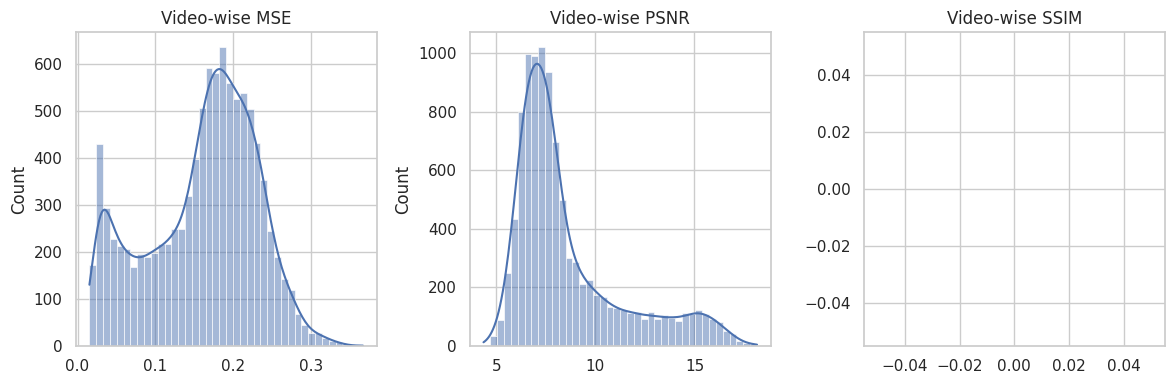

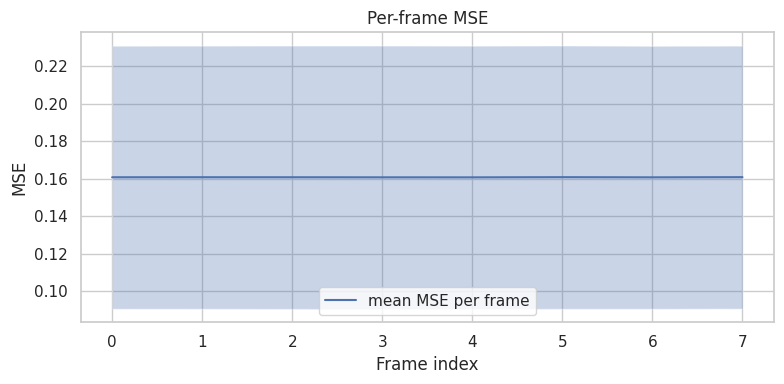

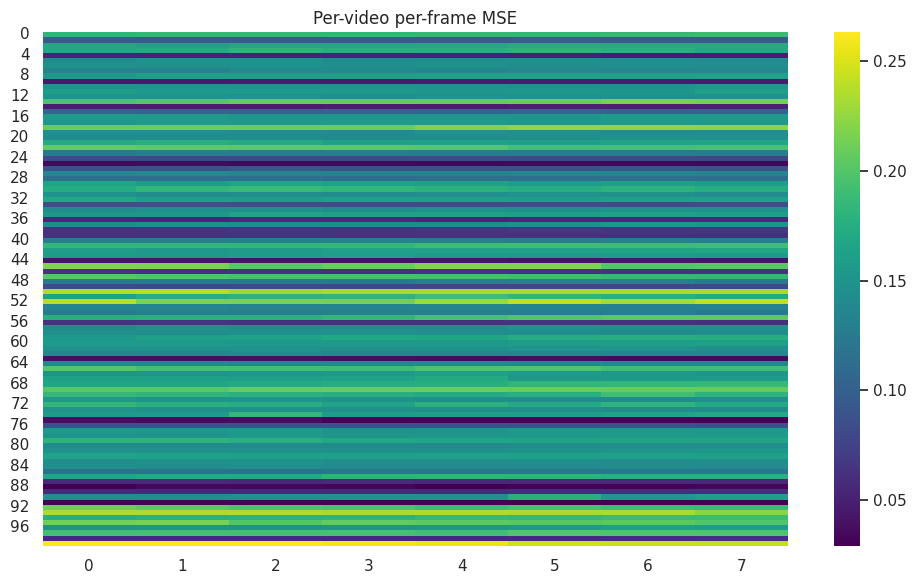

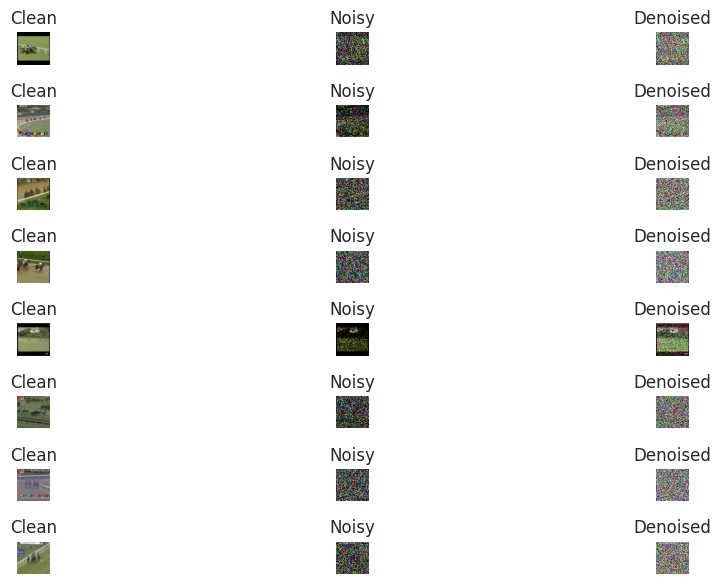

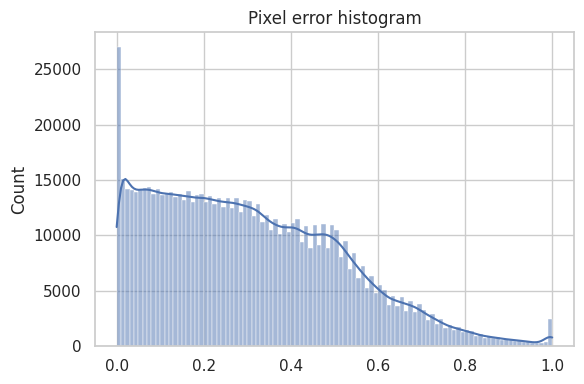

Evaluation complete. Plots saved to /kaggle/working/eval_plots


In [4]:
# Kaggle evaluation cell
# Paste and run this cell in your Kaggle notebook after training or after uploading the checkpoint.

import os
import gc
import torch
from torch.utils.data import DataLoader
from diffusers import UNet3DConditionModel, DDPMScheduler
import torchvision.transforms as T
import numpy as np
import cv2

# --- Aggressive cleanup
gc.collect()
torch.cuda.empty_cache()

# -------------------------
# Recreate VideoDataset from training
# -------------------------
class VideoDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, frame_count=8, image_size=64):
        self.video_files = []
        for root, _, files in os.walk(root_dir):
            for f in files:
                if f.endswith(('.mp4', '.avi')):
                    self.video_files.append(os.path.join(root, f))
        self.frame_count = frame_count
        self.transform = T.Compose([
            T.ToPILImage(), T.Resize((image_size, image_size)),
            T.CenterCrop(image_size), T.ToTensor(), T.Normalize([0.5], [0.5])
        ])

    def __len__(self):
        return len(self.video_files)

    def __getitem__(self, idx):
        cap = cv2.VideoCapture(self.video_files[idx])
        frames = []
        total_v_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 1
        indices = np.linspace(0, max(total_v_frames - 1, 0), self.frame_count).astype(int)
        for i in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
            ret, frame = cap.read()
            if not ret:
                break
            frames.append(self.transform(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))
        cap.release()
        # if video shorter than frame_count, repeat last frame
        if len(frames) == 0:
            # fallback: create black frames
            frames = [torch.zeros_like(self.transform(np.zeros((64,64,3), dtype=np.uint8))) for _ in range(self.frame_count)]
        while len(frames) < self.frame_count:
            frames.append(frames[-1])
        # return shape (C, T, H, W)
        return torch.stack(frames).permute(1, 0, 2, 3)

# -------------------------
# Wrapper used in training
# -------------------------
import torch.nn as nn
class DiffusersModelWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, sample, timesteps, encoder_hidden_states):
        output = self.model(
            sample,
            timesteps,
            encoder_hidden_states=encoder_hidden_states,
            return_dict=False
        )
        return output[0]

# -------------------------
# Import evaluation utilities
# -------------------------
# If you saved eval_video_diffusion.py in the working dir, import it.
# Otherwise the functions are included inline below for convenience.
try:
    from eval_video_diffusion import (
        evaluate_reconstruction, plot_metric_histograms,
        plot_per_frame_mse, plot_error_heatmap, show_sample_reconstructions,
        plot_pixel_error_histogram, plot_training_history
    )
    print("Imported eval_video_diffusion module.")
except Exception as e:
    print("Could not import eval_video_diffusion module, defining minimal evaluation functions inline.")
    # Minimal inline implementations (only what is needed to run)
    import matplotlib.pyplot as plt
    import seaborn as sns
    from skimage.metrics import structural_similarity as ssim
    from skimage.metrics import peak_signal_noise_ratio as psnr
    sns.set(style="whitegrid")
    import numpy as np
    from tqdm import tqdm

    def evaluate_reconstruction(model, dataloader, device, noise_scheduler, max_batches=None, return_samples=8):
        model.eval()
        device = torch.device(device)
        all_mse, all_psnr, all_ssim, per_frame_mse, samples = [], [], [], [], []
        with torch.no_grad():
            for i, batch in enumerate(tqdm(dataloader, desc="Evaluating")):
                if max_batches is not None and i >= max_batches:
                    break
                clean_vids = batch.to(device)
                B = clean_vids.shape[0]
                noise = torch.randn_like(clean_vids)
                timesteps = torch.randint(0, noise_scheduler.num_train_timesteps, (B,), device=device).long()
                noisy_vids = noise_scheduler.add_noise(clean_vids, noise, timesteps)
                dummy_cond = torch.zeros((B, 1, 768), device=device)
                noise_pred = model(noisy_vids, timesteps, dummy_cond)
                if isinstance(noise_pred, (tuple, list)):
                    noise_pred = noise_pred[0]
                denoised = noisy_vids - noise_pred

                def to_numpy_vid(tensor):
                    arr = tensor.detach().cpu().numpy()
                    arr = (arr * 0.5) + 0.5
                    arr = np.clip(arr, 0.0, 1.0)
                    arr = np.transpose(arr, (0, 2, 3, 4, 1))
                    return arr

                clean_np = to_numpy_vid(clean_vids)
                denoised_np = to_numpy_vid(denoised)

                for b in range(B):
                    vid_clean = clean_np[b]
                    vid_deno = denoised_np[b]
                    T_frames = vid_clean.shape[0]
                    frame_mse = np.zeros(T_frames, dtype=float)
                    frame_psnr = np.zeros(T_frames, dtype=float)
                    frame_ssim = np.zeros(T_frames, dtype=float)
                    for t in range(T_frames):
                        a = vid_clean[t]
                        bframe = vid_deno[t]
                        frame_mse[t] = np.mean((a - bframe) ** 2)
                        frame_psnr[t] = psnr(a, bframe, data_range=1.0)
                        try:
                            frame_ssim[t] = ssim(a, bframe, data_range=1.0, multichannel=True)
                        except Exception:
                            frame_ssim[t] = np.nan
                    per_frame_mse.append(frame_mse)
                    all_mse.append(frame_mse.mean())
                    all_psnr.append(frame_psnr.mean())
                    all_ssim.append(np.nanmean(frame_ssim))
                if len(samples) < return_samples:
                    for b in range(min(B, return_samples - len(samples))):
                        samples.append((clean_np[b], noisy_vids.detach().cpu().numpy()[b].transpose(1,2,3,0), denoised_np[b]))
        return {'mse': np.array(all_mse), 'psnr': np.array(all_psnr), 'ssim': np.array(all_ssim),
                'per_frame_mse': per_frame_mse, 'samples': samples}

    import matplotlib.pyplot as plt
    import seaborn as sns
    def plot_metric_histograms(results, out_dir=None):
        if out_dir:
            os.makedirs(out_dir, exist_ok=True)
        plt.figure(figsize=(12,4))
        plt.subplot(1,3,1); sns.histplot(results['mse'], bins=40, kde=True); plt.title('Video-wise MSE')
        plt.subplot(1,3,2); sns.histplot(results['psnr'], bins=40, kde=True); plt.title('Video-wise PSNR')
        plt.subplot(1,3,3); sns.histplot(results['ssim'][~np.isnan(results['ssim'])], bins=40, kde=True); plt.title('Video-wise SSIM')
        plt.tight_layout()
        if out_dir: plt.savefig(os.path.join(out_dir, 'metric_histograms.png'), dpi=150, bbox_inches='tight')
        plt.show()

    def plot_per_frame_mse(per_frame_mse, out_path=None):
        arr = np.stack(per_frame_mse, axis=0)
        mean = arr.mean(axis=0); std = arr.std(axis=0)
        plt.figure(figsize=(8,4)); x = np.arange(len(mean))
        plt.plot(x, mean, label='mean MSE per frame'); plt.fill_between(x, mean-std, mean+std, alpha=0.3)
        plt.xlabel('Frame index'); plt.ylabel('MSE'); plt.title('Per-frame MSE'); plt.legend(); plt.tight_layout()
        if out_path: plt.savefig(out_path, dpi=150, bbox_inches='tight'); 
        plt.show()

    def plot_error_heatmap(per_frame_mse, out_path=None):
        arr = np.stack(per_frame_mse, axis=0)[:100]
        plt.figure(figsize=(10,6)); sns.heatmap(arr, cmap='viridis'); plt.title('Per-video per-frame MSE'); plt.tight_layout()
        if out_path: plt.savefig(out_path, dpi=150, bbox_inches='tight'); plt.show()

    def show_sample_reconstructions(samples, ncols=3, frame_to_show=0, out_path=None, figsize=(12,6)):
        n = len(samples)
        plt.figure(figsize=figsize)
        for i, (clean, noisy, denoised) in enumerate(samples):
            t = min(frame_to_show, clean.shape[0]-1)
            plt.subplot(n, 3, i*3 + 1); plt.imshow(clean[t]); plt.title('Clean'); plt.axis('off')
            plt.subplot(n, 3, i*3 + 2); plt.imshow(noisy[t]); plt.title('Noisy'); plt.axis('off')
            plt.subplot(n, 3, i*3 + 3); plt.imshow(denoised[t]); plt.title('Denoised'); plt.axis('off')
        plt.tight_layout()
        if out_path: plt.savefig(out_path, dpi=150, bbox_inches='tight')
        plt.show()

    def plot_pixel_error_histogram(samples, out_path=None):
        errors = []
        for clean, _, denoised in samples:
            errors.append(np.abs(clean - denoised).ravel())
        if len(errors) == 0:
            print("No samples to plot.")
            return
        errors = np.concatenate(errors)
        plt.figure(figsize=(6,4)); sns.histplot(errors, bins=100, kde=True); plt.title('Pixel error histogram'); plt.tight_layout()
        if out_path: plt.savefig(out_path, dpi=150, bbox_inches='tight'); plt.show()

    def plot_training_history(history, out_path=None):
        plt.figure(figsize=(12,4))
        if 'train_loss' in history or 'val_loss' in history:
            plt.subplot(1,2,1)
            if 'train_loss' in history: plt.plot(history['train_loss'], label='train_loss')
            if 'val_loss' in history: plt.plot(history['val_loss'], label='val_loss')
            plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss'); plt.legend()
        plt.subplot(1,2,2)
        if 'train_mse' in history: plt.plot(history['train_mse'], label='train_mse')
        if 'val_mse' in history: plt.plot(history['val_mse'], label='val_mse')
        plt.xlabel('Epoch'); plt.title('MSE / PSNR'); plt.legend(); plt.tight_layout()
        if out_path: plt.savefig(out_path, dpi=150, bbox_inches='tight')
        plt.show()

# -------------------------
# Kaggle paths and settings
# -------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# Adjust these paths to your dataset and checkpoint locations on Kaggle
VIDEO_PATH = "/kaggle/input/ucf101-action-recognition/train"  # change if needed
CHECKPOINT_PATH = "/kaggle/working/video_model_light_final.pt"  # or upload to this path
OUT_DIR = "/kaggle/working/eval_plots"
os.makedirs(OUT_DIR, exist_ok=True)

# -------------------------
# Build dataset and loader
# -------------------------
frame_count = 8
image_size = 64
batch_size = 2 * max(1, torch.cuda.device_count())
num_workers = 2

dataset = VideoDataset(VIDEO_PATH, frame_count=frame_count, image_size=image_size)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=num_workers)

print(f"Dataset size {len(dataset)} videos. Eval batch size {batch_size}.")

# -------------------------
# Recreate model architecture and load checkpoint if available
# -------------------------
print("Recreating model architecture...")
base_model = UNet3DConditionModel(
    sample_size=image_size,
    in_channels=3,
    out_channels=3,
    cross_attention_dim=768,
    attention_head_dim=8,
    block_out_channels=(32, 64, 128, 128),
    down_block_types=("CrossAttnDownBlock3D", "CrossAttnDownBlock3D", "CrossAttnDownBlock3D", "DownBlock3D"),
    up_block_types=("UpBlock3D", "CrossAttnUpBlock3D", "CrossAttnUpBlock3D", "CrossAttnUpBlock3D"),
).to(DEVICE)

wrapper = DiffusersModelWrapper(base_model)

# If you trained with DataParallel and want to use multiple GPUs for eval, wrap again
if torch.cuda.device_count() > 1:
    wrapper = torch.nn.DataParallel(wrapper)
    print(f"Wrapped model with DataParallel for {torch.cuda.device_count()} GPUs.")

# Load checkpoint if present
if os.path.exists(CHECKPOINT_PATH):
    print("Loading checkpoint:", CHECKPOINT_PATH)
    state = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    # If checkpoint is base model state_dict, load into wrapper.module.model or wrapper.model
    try:
        if isinstance(wrapper, torch.nn.DataParallel):
            wrapper.module.model.load_state_dict(state)
        else:
            wrapper.model.load_state_dict(state)
        print("Checkpoint loaded successfully.")
    except Exception as e:
        print("Failed to load checkpoint directly:", e)
        # try loading into base_model
        try:
            base_model.load_state_dict(state)
            print("Loaded into base_model.")
        except Exception as e2:
            print("Still failed to load checkpoint:", e2)
else:
    print("No checkpoint found at", CHECKPOINT_PATH, "Proceeding with random weights (not recommended).")

# -------------------------
# Create noise scheduler (same as training)
# -------------------------
noise_scheduler = DDPMScheduler(num_train_timesteps=1000)

# -------------------------
# Run evaluation
# -------------------------
print("Running evaluation. This may take time depending on dataset size.")
results = evaluate_reconstruction(
    model=wrapper,
    dataloader=loader,
    device=DEVICE,
    noise_scheduler=noise_scheduler,
    max_batches=None,       # set to small int for quick checks
    return_samples=8
)

# -------------------------
# Plot and save results
# -------------------------
plot_metric_histograms(results, out_dir=OUT_DIR)
plot_per_frame_mse(results['per_frame_mse'], out_path=os.path.join(OUT_DIR, 'per_frame_mse.png'))
plot_error_heatmap(results['per_frame_mse'], out_path=os.path.join(OUT_DIR, 'error_heatmap.png'))
show_sample_reconstructions(results['samples'], frame_to_show=3, out_path=os.path.join(OUT_DIR, 'samples.png'))
plot_pixel_error_histogram(results['samples'], out_path=os.path.join(OUT_DIR, 'pixel_error_hist.png'))

print("Evaluation complete. Plots saved to", OUT_DIR)

In [ ]:
from eval_video_diffusion import (
    evaluate_reconstruction, plot_metric_histograms,
    plot_per_frame_mse, plot_error_heatmap, show_sample_reconstructions,
    plot_pixel_error_histogram, plot_training_history
)
import torch

# load your model wrapper exactly as used in training
# if you saved state_dict of base_model, re-create wrapper and load state_dict into wrapper.model
# Example: (assuming same model creation code)
# base_model = UNet3DConditionModel(...).to(DEVICE)
# wrapper = DiffusersModelWrapper(base_model)
# if using DataParallel in training and you want to use single GPU now, wrap accordingly
# wrapper.model.load_state_dict(torch.load('/kaggle/working/video_model_light_final.pt'))

# Use the same 'model' variable you used in training (wrapper or DataParallel wrapper)
# model = ... (load weights as needed)
model.eval()

# Evaluate
results = evaluate_reconstruction(
    model=model,
    dataloader=loader,         # your DataLoader from training or a test loader
    device='cuda',
    noise_scheduler=noise_scheduler,
    max_batches=None,          # set small number for quick checks
    return_samples=8
)

# Plot distributions and diagnostics
plot_metric_histograms(results, out_dir='/kaggle/working/eval_plots')
plot_per_frame_mse(results['per_frame_mse'], out_path='/kaggle/working/eval_plots/per_frame_mse.png')
plot_error_heatmap(results['per_frame_mse'], out_path='/kaggle/working/eval_plots/error_heatmap.png')
show_sample_reconstructions(results['samples'], frame_to_show=3, out_path='/kaggle/working/eval_plots/samples.png')
plot_pixel_error_histogram(results['samples'], out_path='/kaggle/working/eval_plots/pixel_error_hist.png')

# If you recorded training history during training, plot it:
# history = {'train_loss': [...], 'val_loss': [...], 'train_mse': [...], 'val_mse': [...]} 
# plot_training_history(history, out_path='/kaggle/working/eval_plots/training_history.png')

In [2]:
# eval_video_diffusion.py
import os
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import torch
import torch.nn.functional as F
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

sns.set(style="whitegrid")

# -------------------------
# Helpers for model unwrapping
# -------------------------
def _unwrap_model(model):
    """
    Return the underlying wrapper used in training so we can call it the same way.
    Training used DiffusersModelWrapper (wrapper.model) and possibly nn.DataParallel.
    We want to call model(noisy, timesteps, cond) exactly like training did.
    This function returns the same object you should call in eval (model).
    """
    # If DataParallel was used, model is nn.DataParallel(wrapper)
    # wrapper has attribute .model (the base UNet3DConditionModel)
    return model

# -------------------------
# Reconstruction helper
# -------------------------
def reconstruct_from_noise_pred(noisy_vids, noise_pred):
    """
    Given noisy videos and predicted noise, reconstruct denoised videos:
    denoised = noisy - predicted_noise
    Both inputs are torch tensors on same device.
    """
    return noisy_vids - noise_pred

# -------------------------
# Metric functions (per video / per frame)
# -------------------------
def compute_mse(a, b):
    return np.mean((a - b) ** 2)

def compute_psnr(a, b, data_range=1.0):
    # skimage expects images in [0,1] or [0,255] depending on data_range
    return psnr(a, b, data_range=data_range)

def compute_ssim_per_frame(a, b):
    # a,b are HxW x C arrays in [0,1]
    # compute mean SSIM across channels by converting to grayscale-like average
    if a.ndim == 3 and a.shape[2] == 3:
        # skimage ssim supports multichannel
        return ssim(a, b, data_range=1.0, multichannel=True)
    else:
        return ssim(a.squeeze(), b.squeeze(), data_range=1.0)

# -------------------------
# Main evaluation loop
# -------------------------
def evaluate_reconstruction(model, dataloader, device, noise_scheduler, max_batches=None, return_samples=8):
    """
    Evaluate the diffusion model's denoising performance on dataloader.
    - model: the same wrapper you used in training (DiffusersModelWrapper or DataParallel wrapper)
    - dataloader: yields tensors shaped (B, C, T, H, W) as in your dataset
    - device: 'cuda' or 'cpu'
    - noise_scheduler: DDPMScheduler instance used in training (for add_noise)
    - max_batches: optional limit for quick runs
    - return_samples: number of sample videos to keep for visualization
    Returns a dict with aggregated metrics and sample arrays for plotting.
    """
    model = _unwrap_model(model)
    model.eval()

    all_mse = []
    all_psnr = []
    all_ssim = []
    per_frame_mse = []  # list of arrays (T,)
    samples = []  # store tuples (clean, noisy, denoised) as numpy arrays for visualization

    device = torch.device(device)
    with torch.no_grad():
        for i, batch in enumerate(tqdm(dataloader, desc="Evaluating")):
            if max_batches is not None and i >= max_batches:
                break

            # batch shape: (B, C, T, H, W)
            clean_vids = batch.to(device)
            B = clean_vids.shape[0]

            # create noise and timesteps similar to training
            noise = torch.randn_like(clean_vids)
            timesteps = torch.randint(0, noise_scheduler.num_train_timesteps, (B,), device=device).long()

            noisy_vids = noise_scheduler.add_noise(clean_vids, noise, timesteps)

            # dummy conditioning as in training (1,768) per sample
            dummy_cond = torch.zeros((B, 1, 768), device=device)

            # model returns predicted noise (same shape as clean_vids)
            noise_pred = model(noisy_vids, timesteps, dummy_cond)
            # ensure tensor
            if isinstance(noise_pred, tuple) or isinstance(noise_pred, list):
                noise_pred = noise_pred[0]

            denoised = reconstruct_from_noise_pred(noisy_vids, noise_pred)

            # move to cpu numpy in [0,1] range for metrics and plotting
            # note: training normalized images with mean=0.5 std=0.5 -> original = (x*0.5)+0.5
            def to_numpy_vid(tensor):
                # tensor shape (B,C,T,H,W)
                arr = tensor.detach().cpu().numpy()
                # unnormalize
                arr = (arr * 0.5) + 0.5
                arr = np.clip(arr, 0.0, 1.0)
                # convert to shape (B, T, H, W, C)
                arr = np.transpose(arr, (0, 2, 3, 4, 1))
                return arr

            clean_np = to_numpy_vid(clean_vids)
            noisy_np = to_numpy_vid(noisy_vids)
            denoised_np = to_numpy_vid(denoised)

            # compute metrics per video and per frame
            for b in range(B):
                vid_clean = clean_np[b]      # (T,H,W,C)
                vid_deno = denoised_np[b]
                T_frames = vid_clean.shape[0]

                frame_mse = np.zeros(T_frames, dtype=float)
                frame_psnr = np.zeros(T_frames, dtype=float)
                frame_ssim = np.zeros(T_frames, dtype=float)

                for t in range(T_frames):
                    a = vid_clean[t]
                    bframe = vid_deno[t]
                    frame_mse[t] = compute_mse(a, bframe)
                    # PSNR expects data_range; images in [0,1]
                    frame_psnr[t] = compute_psnr(a, bframe, data_range=1.0)
                    try:
                        frame_ssim[t] = compute_ssim_per_frame(a, bframe)
                    except Exception:
                        frame_ssim[t] = np.nan

                per_frame_mse.append(frame_mse)
                all_mse.append(frame_mse.mean())
                all_psnr.append(frame_psnr.mean())
                all_ssim.append(np.nanmean(frame_ssim))

            # collect sample videos for visualization
            if len(samples) < return_samples:
                for b in range(min(B, return_samples - len(samples))):
                    samples.append((clean_np[b], noisy_np[b], denoised_np[b]))

    results = {
        'mse': np.array(all_mse),
        'psnr': np.array(all_psnr),
        'ssim': np.array(all_ssim),
        'per_frame_mse': per_frame_mse,  # list of arrays
        'samples': samples
    }
    return results

# -------------------------
# Plotting utilities
# -------------------------
def plot_training_history(history, out_path=None):
    """
    history: dict with keys 'train_loss', 'val_loss', 'train_mse', 'val_mse', etc.
    """
    plt.figure(figsize=(12,4))
    # Loss
    if 'train_loss' in history or 'val_loss' in history:
        plt.subplot(1,2,1)
        if 'train_loss' in history:
            plt.plot(history['train_loss'], label='train_loss')
        if 'val_loss' in history:
            plt.plot(history['val_loss'], label='val_loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Loss curve')
        plt.legend()

    # MSE or PSNR
    plt.subplot(1,2,2)
    if 'train_mse' in history:
        plt.plot(history['train_mse'], label='train_mse')
    if 'val_mse' in history:
        plt.plot(history['val_mse'], label='val_mse')
    if 'train_psnr' in history:
        plt.plot(history['train_psnr'], label='train_psnr')
    if 'val_psnr' in history:
        plt.plot(history['val_psnr'], label='val_psnr')
    plt.xlabel('Epoch')
    plt.title('MSE / PSNR')
    plt.legend()
    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()

def plot_metric_histograms(results, out_dir=None):
    """
    results: dict returned by evaluate_reconstruction
    """
    os.makedirs(out_dir, exist_ok=True) if out_dir else None

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    sns.histplot(results['mse'], bins=40, kde=True)
    plt.title('Video-wise MSE distribution')

    plt.subplot(1,3,2)
    sns.histplot(results['psnr'], bins=40, kde=True)
    plt.title('Video-wise PSNR distribution')

    plt.subplot(1,3,3)
    sns.histplot(results['ssim'][~np.isnan(results['ssim'])], bins=40, kde=True)
    plt.title('Video-wise SSIM distribution')

    plt.tight_layout()
    if out_dir:
        plt.savefig(os.path.join(out_dir, 'metric_histograms.png'), dpi=150, bbox_inches='tight')
    plt.show()

def plot_per_frame_mse(per_frame_mse, out_path=None):
    """
    per_frame_mse: list of arrays (T,)
    Plot mean and std across dataset per frame index.
    """
    arr = np.stack(per_frame_mse, axis=0)  # (N_videos, T)
    mean = arr.mean(axis=0)
    std = arr.std(axis=0)

    plt.figure(figsize=(8,4))
    x = np.arange(len(mean))
    plt.plot(x, mean, label='mean MSE per frame')
    plt.fill_between(x, mean - std, mean + std, alpha=0.3, label='std')
    plt.xlabel('Frame index')
    plt.ylabel('MSE')
    plt.title('Per-frame MSE across dataset')
    plt.legend()
    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()

def plot_error_heatmap(per_frame_mse, out_path=None):
    """
    Show a heatmap of per-video vs frame MSE for a subset of videos.
    """
    arr = np.stack(per_frame_mse, axis=0)  # (N, T)
    # limit to first 100 videos for readability
    arr_small = arr[:100]
    plt.figure(figsize=(10,6))
    sns.heatmap(arr_small, cmap='viridis', cbar_kws={'label': 'MSE'})
    plt.xlabel('Frame index')
    plt.ylabel('Video index (subset)')
    plt.title('Per-video per-frame MSE heatmap (first 100 videos)')
    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()

def show_sample_reconstructions(samples, ncols=3, frame_to_show=0, out_path=None, figsize=(12,6)):
    """
    samples: list of tuples (clean_vid, noisy_vid, denoised_vid) where each vid is (T,H,W,C) in [0,1]
    frame_to_show: which frame index to display from each video
    """
    n = len(samples)
    plt.figure(figsize=figsize)
    for i, (clean, noisy, denoised) in enumerate(samples):
        if i >= n: break
        # choose frame index safely
        t = min(frame_to_show, clean.shape[0]-1)
        # Clean
        plt.subplot(n, 3, i*3 + 1)
        plt.imshow(clean[t])
        plt.title('Clean')
        plt.axis('off')
        # Noisy
        plt.subplot(n, 3, i*3 + 2)
        plt.imshow(noisy[t])
        plt.title('Noisy')
        plt.axis('off')
        # Denoised
        plt.subplot(n, 3, i*3 + 3)
        plt.imshow(denoised[t])
        plt.title('Denoised')
        plt.axis('off')
    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()

def plot_pixel_error_histogram(samples, out_path=None):
    """
    Plot histogram of pixel-wise absolute errors across sample reconstructions.
    """
    errors = []
    for clean, _, denoised in samples:
        # flatten per-pixel absolute error
        errors.append(np.abs(clean - denoised).ravel())
    if len(errors) == 0:
        print("No samples to plot pixel error histogram.")
        return
    errors = np.concatenate(errors)
    plt.figure(figsize=(6,4))
    sns.histplot(errors, bins=100, kde=True)
    plt.xlabel('Absolute pixel error')
    plt.title('Pixel-wise absolute error histogram (samples)')
    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()

# -------------------------
# Example usage
# -------------------------
if __name__ == "__main__":
    print("This module provides evaluate_reconstruction(...) and plotting helpers.")
    print("Import and call evaluate_reconstruction(model, loader, device, noise_scheduler).")

This module provides evaluate_reconstruction(...) and plotting helpers.
Import and call evaluate_reconstruction(model, loader, device, noise_scheduler).
